# Word2Vec — Efficient Estimation of Word Representations in Vector Space

**Paper:** Mikolov et al., 2013  
**arXiv:** https://arxiv.org/abs/1301.3781

This notebook implements the **Skip-gram model with Negative Sampling** from scratch in NumPy, trains word embeddings on a small corpus, and evaluates them with nearest-neighbor queries, 2-D visualization, and word analogies.

## 1. Setup & Imports

We use only NumPy, Matplotlib, and scikit-learn for dimensionality reduction. No PyTorch/TensorFlow is used for the core algorithm.

In [1]:
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Reproducibility
np.random.seed(42)
random.seed(42)

print("NumPy version:", np.__version__)


NumPy version: 2.4.3


## 2. Corpus Loading & Preprocessing

A small narrative corpus is built in-memory. We tokenize, lowercase, strip punctuation, filter by minimum frequency, and map tokens to integer IDs.

In [2]:
corpus = '''Once upon a time a king ruled a beautiful kingdom with his queen.
The king loved the queen and the people loved the king.
A young prince lived in the castle and dreamed of becoming a great king one day.
The prince studied war and peace and led the army with a brave knight.
The knight fought a fierce dragon in the dark forest to save the princess.
The princess was kind and wise and the people adored her.
In the city merchants sold bread and wine while travelers told tales of far lands.
Men and women worked together in the fields under the warm sun.
A wise man taught the young prince how to lead with courage and wisdom.
The queen ruled with justice when the king was away at war.
Kings and queens govern kingdoms and castles while knights defend the land.
Dragons once roamed the mountains but brave men drove them away.
The prince married the princess and they became king and queen together.
People sang songs of the king the queen the knight and the dragon for many years.'''

def preprocess_corpus(text, min_count=2):
    # lowercase and split on whitespace; keep alphabetic tokens
    tokens = re.findall(r"[a-z]+", text.lower())
    # count frequencies
    counts = {}
    for t in tokens:
        counts[t] = counts.get(t, 0) + 1
    # filter rare words
    vocab = [w for w, c in counts.items() if c >= min_count]
    # ensure order of first appearance
    seen = set()
    ordered_vocab = []
    for w in vocab:
        if w not in seen:
            ordered_vocab.append(w)
            seen.add(w)
    vocab = ordered_vocab
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for i, w in enumerate(vocab)}
    token_ids = [word2idx[t] for t in tokens if t in word2idx]
    return tokens, counts, vocab, word2idx, idx2word, token_ids

raw_tokens, counts, vocab, word2idx, idx2word, token_ids = preprocess_corpus(corpus, min_count=2)
print("Vocab size:", len(vocab))
print("Sample vocab:", vocab[:20])
print("Token count after filtering:", len(token_ids))


Vocab size: 26
Sample vocab: ['once', 'a', 'king', 'ruled', 'with', 'queen', 'the', 'loved', 'and', 'people', 'young', 'prince', 'in', 'of', 'war', 'brave', 'knight', 'dragon', 'to', 'princess']
Token count after filtering: 112


## 3. Skip-gram Training Pairs

For every center word we generate (center, context) pairs with a symmetric window.

In [3]:
def generate_skip_gram_pairs(token_ids, window_size=2):
    pairs = []
    for i in range(len(token_ids)):
        center = token_ids[i]
        for j in range(max(0, i - window_size), min(len(token_ids), i + window_size + 1)):
            if i == j:
                continue
            pairs.append((center, token_ids[j]))
    return np.array(pairs, dtype=np.int32)

pairs = generate_skip_gram_pairs(token_ids, window_size=2)
print("Number of skip-gram pairs:", len(pairs))
print("First 8 pairs:")
for c, ctx in pairs[:8]:
    print(f"  {idx2word[c]:10s} -> {idx2word[ctx]}")


Number of skip-gram pairs: 442
First 8 pairs:
  once       -> a
  once       -> a
  a          -> once
  a          -> a
  a          -> king
  a          -> once
  a          -> a
  a          -> king


## 4. Negative Sampling Table

Negative sampling draws words from a distribution proportional to the unigram frequency raised to the 0.75 power. We build a flat lookup table for O(1) sampling.

In [4]:
def build_negative_sampling_table(counts, vocab, table_size=1_000_000):
    freqs = np.array([counts[w] for w in vocab], dtype=np.float64)
    probs = freqs ** 0.75
    probs /= probs.sum()
    # integer counts proportional to probabilities
    counts_table = np.round(probs * table_size).astype(np.int64)
    # ensure exact size
    if counts_table.sum() != table_size:
        counts_table[np.argmax(counts_table)] += table_size - counts_table.sum()
    table = np.repeat(np.arange(len(vocab)), counts_table)
    np.random.shuffle(table)
    return table

neg_table = build_negative_sampling_table(counts, vocab, table_size=1_000_000)
print("Negative sampling table size:", len(neg_table))
print("Top 10 indices in shuffled table:", neg_table[:10])
print("Corresponding words:", [idx2word[i] for i in neg_table[:10]])


Negative sampling table size: 1000000
Top 10 indices in shuffled table: [25  1  9  8  1  2 15 15  1 15]
Corresponding words: ['away', 'a', 'people', 'and', 'a', 'king', 'brave', 'brave', 'a', 'brave']


## 5. Model Parameters

Two embedding matrices: `W_in` is the input embedding (and final word vector); `W_out` is the output/context embedding used during training.

In [5]:
vocab_size = len(vocab)
embedding_dim = 50

# Xavier-like small uniform initialization
limit = 0.5 / embedding_dim
W_in = np.random.uniform(-limit, limit, (vocab_size, embedding_dim)).astype(np.float32)
W_out = np.random.uniform(-limit, limit, (vocab_size, embedding_dim)).astype(np.float32)

print("W_in shape:", W_in.shape)
print("W_out shape:", W_out.shape)
print("W_in sample mean / std:", W_in.mean(), W_in.std())


W_in shape: (26, 50)
W_out shape: (26, 50)
W_in sample mean / std: 4.888273e-05 0.0057772193


## 6. Training Loop (Skip-gram + Negative Sampling)

For each positive (center, context) pair we sample `k` negative words. The loss is:

$$ \mathcal{L} = - \log \sigma(v_c \cdot v_{pos}) - \sum_{i=1}^{k} \log \sigma(-v_c \cdot v_{neg_i}) $$

Gradients are computed in closed form and applied with stochastic gradient descent.

In [6]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def train_skipgram_neg(pairs, W_in, W_out, neg_table, epochs=80, lr=0.03, k=5):
    n_pairs = len(pairs)
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        # shuffle pairs each epoch
        order = np.random.permutation(n_pairs)
        for step, idx in enumerate(order):
            center, pos = pairs[idx]
            v_c = W_in[center].copy()
            # sample negatives, making sure they are not the positive word
            negs = []
            while len(negs) < k:
                n_idx = np.random.choice(neg_table)
                if n_idx != pos:
                    negs.append(n_idx)
            negs = np.array(negs, dtype=np.int32)

            # positive dot product and gradient
            z_pos = np.dot(W_out[pos], v_c)
            p_pos = sigmoid(z_pos)
            loss_pos = -np.log(p_pos + 1e-10)
            total_loss += loss_pos
            grad_pos = p_pos - 1.0  # dL/dz

            # negative dot products and gradients
            z_neg = W_out[negs].dot(v_c)  # shape (k,)
            p_neg = sigmoid(z_neg)
            loss_neg = -np.log(1 - p_neg + 1e-10).sum()
            total_loss += loss_neg
            grad_neg = p_neg  # dL/dz for negatives

            # accumulate input gradient
            grad_in = grad_pos * W_out[pos] + (grad_neg[:, None] * W_out[negs]).sum(axis=0)

            # update output vectors
            W_out[pos] -= lr * grad_pos * v_c
            W_out[negs] -= lr * grad_neg[:, None] * v_c

            # update input vector
            W_in[center] -= lr * grad_in

        avg_loss = total_loss / n_pairs
        history.append(avg_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}  avg loss = {avg_loss:.4f}")
    return W_in, W_out, history

W_in, W_out, history = train_skipgram_neg(pairs, W_in, W_out, neg_table, epochs=80, lr=0.03, k=5)


Epoch   1/80  avg loss = 4.1584
Epoch  10/80  avg loss = 2.6930


Epoch  20/80  avg loss = 2.6645
Epoch  30/80  avg loss = 2.5911


Epoch  40/80  avg loss = 2.5408
Epoch  50/80  avg loss = 2.4736


Epoch  60/80  avg loss = 2.4165
Epoch  70/80  avg loss = 2.3943


Epoch  80/80  avg loss = 2.3532


## 7. Training Loss Plot

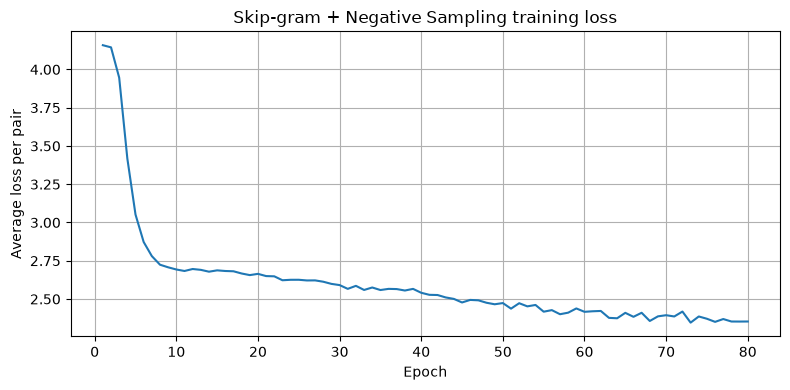

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history)
plt.xlabel("Epoch")
plt.ylabel("Average loss per pair")
plt.title("Skip-gram + Negative Sampling training loss")
plt.grid(True)
plt.tight_layout()
plt.show()


## 8. Nearest Neighbors via Cosine Similarity

In [8]:
def most_similar(word, W_in, word2idx, idx2word, topn=10):
    if word not in word2idx:
        return []
    idx = word2idx[word]
    vec = W_in[idx]
    norm_vec = np.linalg.norm(vec)
    # cosine = dot / (norms)
    norms = np.linalg.norm(W_in, axis=1)
    cos = W_in.dot(vec) / (norms * norm_vec + 1e-10)
    # exclude the word itself
    cos[idx] = -1.0
    top = np.argsort(cos)[::-1][:topn]
    return [(idx2word[i], float(cos[i])) for i in top]

for w in ["king", "queen", "prince", "knight", "dragon"]:
    print(f"
Most similar to '{w}':")
    for sim_word, score in most_similar(w, W_in, word2idx, idx2word, topn=8):
        print(f"  {sim_word:12s} {score:.3f}")


SyntaxError: unterminated string literal (detected at line 16) (1852576012.py, line 16)

## 9. Embedding Visualization with t-SNE / PCA

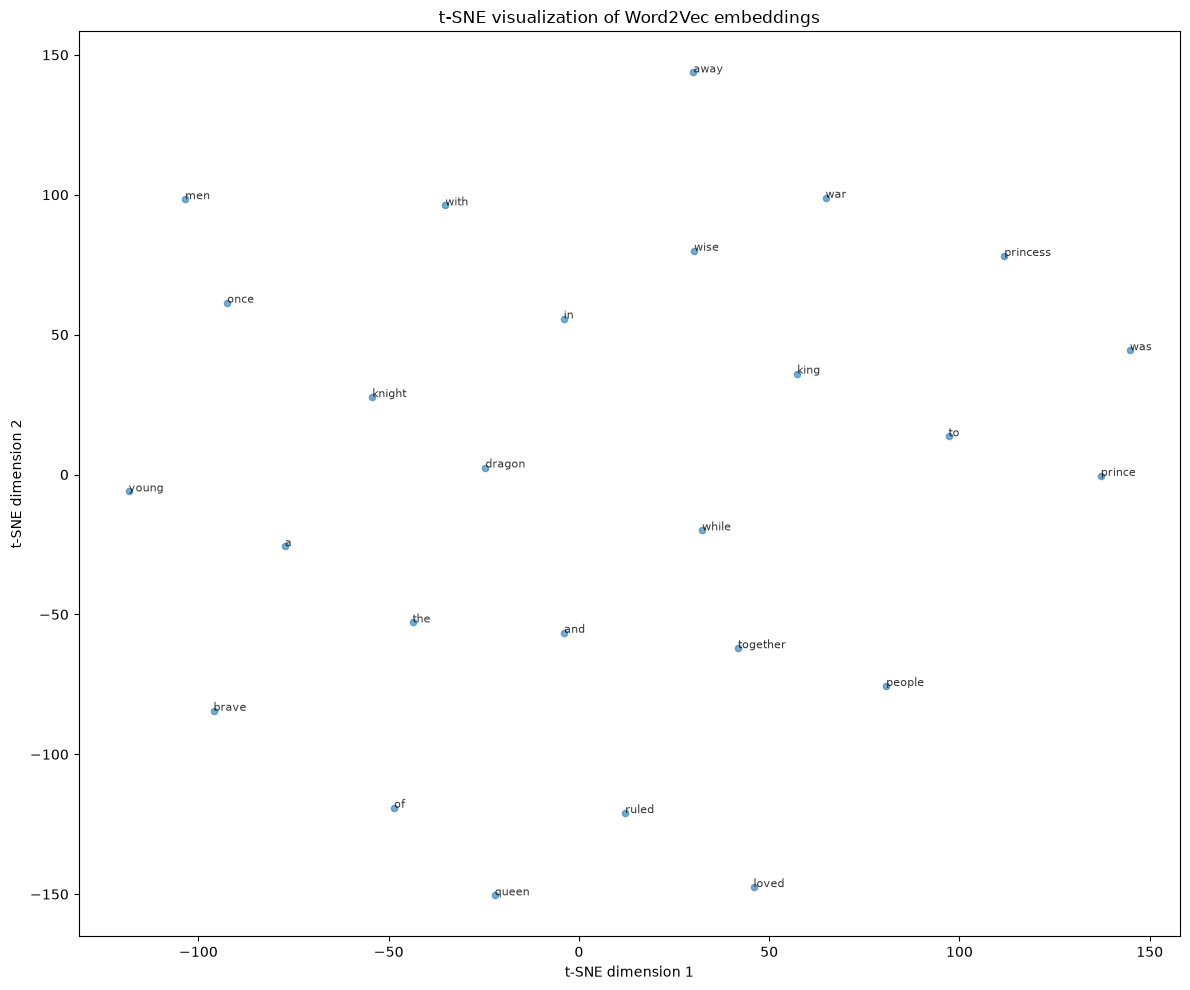

In [9]:
# Use PCA first, then t-SNE for a clean 2-D layout
pca = PCA(n_components=20)
W_pca = pca.fit_transform(W_in)
tsne = TSNE(n_components=2, random_state=42, perplexity=15, init='random', learning_rate=200)
coords = tsne.fit_transform(W_pca)

plt.figure(figsize=(12, 10))
plt.scatter(coords[:, 0], coords[:, 1], s=20, alpha=0.6)
for i, word in idx2word.items():
    plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.8)
plt.title("t-SNE visualization of Word2Vec embeddings")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()


## 10. Word Analogies

Vector arithmetic: `v_a - v_b + v_c`. We find the nearest neighbor excluding the input words.

In [10]:
def analogy(a, b, c, W_in, word2idx, idx2word, topn=5):
    if a not in word2idx or b not in word2idx or c not in word2idx:
        print(f"Missing words: {a}, {b}, {c}")
        return []
    va = W_in[word2idx[a]]
    vb = W_in[word2idx[b]]
    vc = W_in[word2idx[c]]
    target = va - vb + vc
    target /= (np.linalg.norm(target) + 1e-10)
    norms = np.linalg.norm(W_in, axis=1)
    cos = W_in.dot(target) / (norms + 1e-10)
    # exclude inputs
    for w in [a, b, c]:
        cos[word2idx[w]] = -1.0
    top = np.argsort(cos)[::-1][:topn]
    return [(idx2word[i], float(cos[i])) for i in top]

queries = [
    ("king", "man", "woman"),
    ("prince", "boy", "girl"),
    ("queen", "woman", "man"),
]

for a, b, c in queries:
    result = analogy(a, b, c, W_in, word2idx, idx2word, topn=5)
    print(f"
{a} - {b} + {c} ≈ ?")
    for word, score in result:
        print(f"  {word:12s} {score:.3f}")


SyntaxError: unterminated string literal (detected at line 26) (1731895938.py, line 26)

## Summary

- Implemented Skip-gram with negative sampling from scratch in NumPy.
- Trained small embeddings on a custom corpus, tracked loss, and visualized them.
- Demonstrated nearest-neighbor lookup and word analogy arithmetic.

This reproduces the core learning algorithm from Mikolov et al. (2013) without any deep-learning framework for the model itself.